In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from collections import Counter
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

In [4]:
df = pd.read_csv("spam.csv", encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [6]:
df.describe()
df.isnull().sum()

,0
v1,0
v2,0
Unnamed: 2,5522
Unnamed: 3,5560
Unnamed: 4,5566


In [7]:
df = df[['v1','v2']]
df.columns = ['label','message']

In [8]:
print("Duplicate Messages :", df.duplicated().sum())

Duplicate Messages : 403


In [9]:
df = df.drop_duplicates()

In [10]:
print(df.shape)

(5169, 2)


In [11]:
df['label'] = df['label'].map({
    'ham':0,
    'spam':1
})

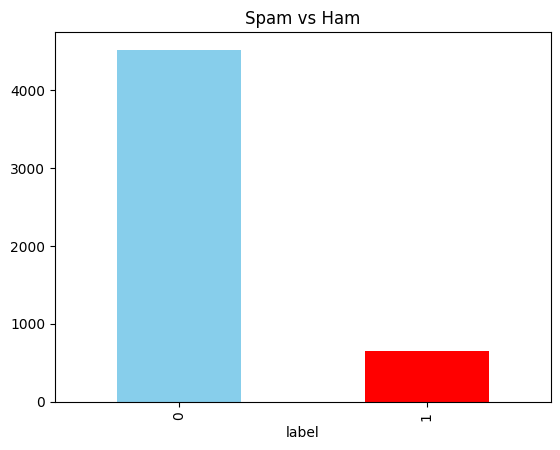

In [12]:
df['label'].value_counts().plot(
    kind='bar',
    color=['skyblue','red']
)

plt.title("Spam vs Ham")
plt.show()

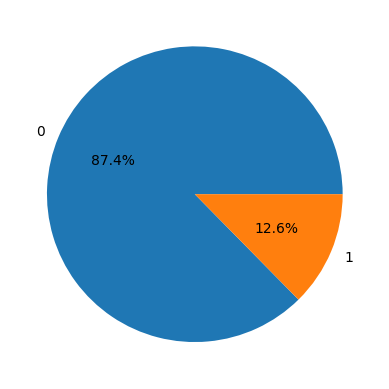

In [13]:
df['label'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel("")
plt.show()

In [14]:
df['length'] = df['message'].apply(len)

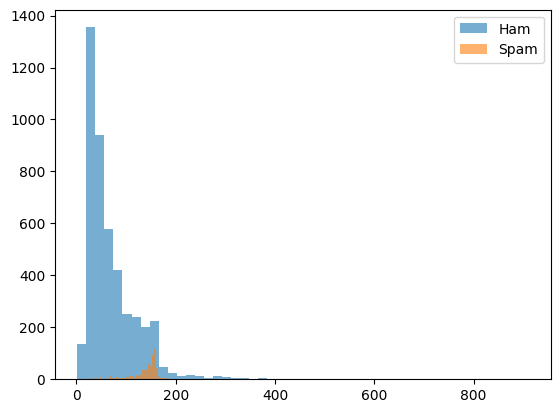

In [15]:
plt.hist(
    df[df.label==0]['length'],
    bins=50,
    alpha=0.6,
    label='Ham'
)

plt.hist(
    df[df.label==1]['length'],
    bins=50,
    alpha=0.6,
    label='Spam'
)

plt.legend()
plt.show()

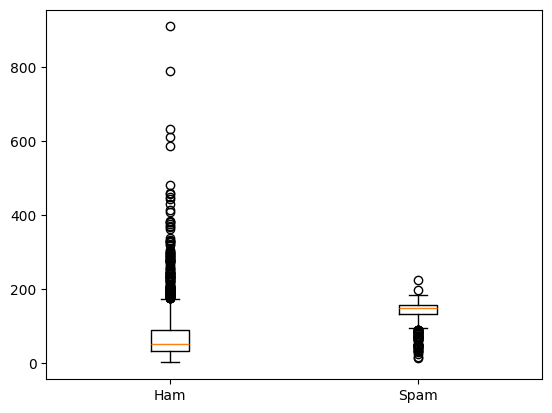

In [16]:
plt.boxplot([
    df[df.label==0]['length'],
    df[df.label==1]['length']
])

plt.xticks([1,2],['Ham','Spam'])
plt.show()

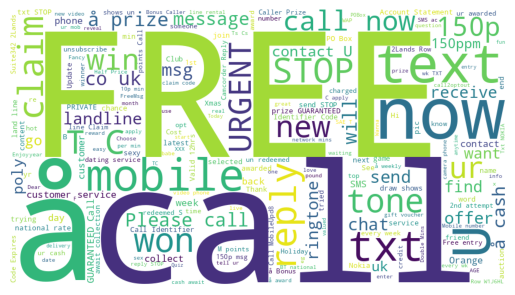

In [17]:
spam = " ".join(df[df.label==1]['message'])

wc = WordCloud(
    width=900,
    height=500,
    background_color='white'
).generate(spam)

plt.imshow(wc)
plt.axis("off")
plt.show()

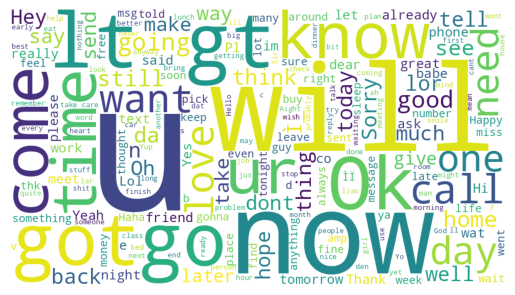

In [18]:
ham = " ".join(df[df.label==0]['message'])

wc = WordCloud(
    width=900,
    height=500,
    background_color='white'
).generate(ham)

plt.imshow(wc)
plt.axis("off")
plt.show()

In [19]:
X = df['message']
y = df['label']

In [20]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X = tfidf.fit_transform(X)

In [21]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
nb = MultinomialNB()

nb.fit(X_train,y_train)

pred_nb = nb.predict(X_test)

In [23]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)

In [24]:
svm = LinearSVC()

svm.fit(X_train,y_train)

pred_svm = svm.predict(X_test)

In [25]:
print("Naive Bayes :",accuracy_score(y_test,pred_nb))

print("Logistic Regression :",accuracy_score(y_test,pred_lr))

print("SVM :",accuracy_score(y_test,pred_svm))

Naive Bayes : 0.9709864603481625
Logistic Regression : 0.9574468085106383
SVM : 0.9825918762088974


In [26]:
print(classification_report(y_test,pred_svm))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       889
           1       0.99      0.88      0.93       145

    accuracy                           0.98      1034
   macro avg       0.99      0.94      0.96      1034
weighted avg       0.98      0.98      0.98      1034



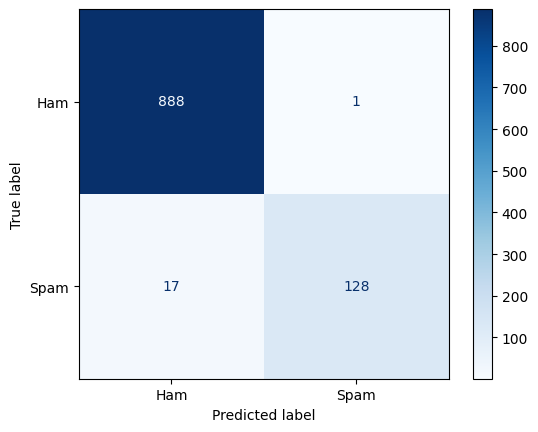

In [27]:
cm = confusion_matrix(y_test,pred_svm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ham","Spam"]
)

disp.plot(cmap='Blues')

plt.show()

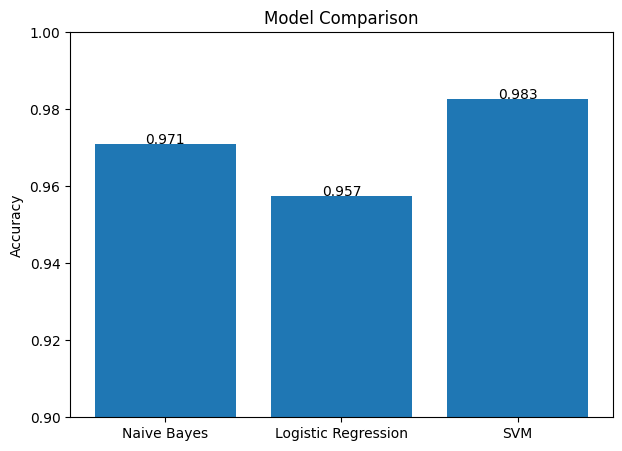

In [28]:
models = [
    "Naive Bayes",
    "Logistic Regression",
    "SVM"
]

accuracy = [
    accuracy_score(y_test,pred_nb),
    accuracy_score(y_test,pred_lr),
    accuracy_score(y_test,pred_svm)
]

plt.figure(figsize=(7,5))

bars = plt.bar(models, accuracy)

plt.ylim(0.90,1.0)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.3f}",
        ha='center'
    )

plt.ylabel("Accuracy")
plt.title("Model Comparison")

plt.show()

In [29]:
message = ["Congratulations! You have won a FREE iPhone. Click here now."]

vector = tfidf.transform(message)

prediction = svm.predict(vector)

if prediction[0] == 1:
    print("Spam Message")
else:
    print("Ham Message")

Spam Message
